<a href="https://colab.research.google.com/github/Serg2311-prog/cub-bird-classification-resnet18/blob/main/HW_5_ver4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи

В этом ноутбуке мы решаем задачу кластеризации данных физической активности на основе датасета PAMAP2-подобного. Данные включают показания IMU-сенсоров (акселерометр, гироскоп, магнитометр) с трех позиций (рука, грудь, лодыжка) и пульсометр, всего около 54 признаков.

Цель: Разделить данные на кластеры, соответствующие различным видам активности (например, ходьба, бег, езда на велосипеде и т.д.), используя методы кластеризации KMeans, DBSCAN и HDBSCAN.

Метрики качества: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index.

Верификация: Визуализация кластеров с помощью PCA/t-SNE, анализ устойчивости моделей.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import hdbscan

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Путь к датасету
DATA_PATH = "clustering-physical-activity-data/Physical_Activity_Monitoring_unlabeled.csv"

# Проверка
if not os.path.exists(DATA_PATH):
    print("Текущая директория:", os.getcwd())
    raise FileNotFoundError(f"Файл не найден: {DATA_PATH}")

# Загрузка
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Данные загружены: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
display(df.head())

Данные загружены: 534,601 строк, 53 столбцов


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6


# Первичный анализ

Проведем базовый анализ структуры данных: размер, типы данных, описательные статистики.

In [ ]:
print("Shape:", df.shape)

print("\nПервые строки:")
display(df.head())

print("\nТипы данных:")
display(df.dtypes)

print("\nСтатистика:")
display(df.describe())

print("\nПропуски:")
missing = df.isna().sum()
display(missing[missing > 0])

print("\nДоля пропусков (%):")
display((df.isna().mean() * 100).sort_values(ascending=False))

print("\nДубликаты:")
print(df.duplicated().sum())

Shape: (534601, 53)

Первые строки:


,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,252.75,34.8750,0.902847,7.45872,6.032490,1.006100,7.44575,6.303650,-0.021952,0.004114,...,-0.025606,0.030239,-14.5447,27.3336,-5.76620,0.206416,0.348212,0.763201,-0.503652,5
1,3652.45,29.7500,-4.069330,3.76168,8.279720,-5.972500,3.22273,6.908970,0.116054,-0.375968,...,-0.670163,1.786200,-32.8257,-15.7719,-1.31395,0.578332,-0.566734,0.405888,-0.423791,2
2,504.76,34.3750,-2.007540,-9.60180,0.773674,-1.803500,-9.58937,1.073680,0.020131,0.042189,...,-0.009741,-0.006579,-18.8171,16.3089,25.29280,0.139776,0.676586,0.393796,0.606316,8
3,2801.61,31.9375,-13.262200,5.85443,0.899334,-13.611500,5.91511,0.840377,1.715630,-0.050492,...,-0.163470,-3.495570,-26.7418,34.3566,21.32740,0.416303,0.783387,0.306464,0.345075,2
4,441.01,33.5000,-0.013940,8.66540,4.398210,0.144153,8.56816,4.822200,-0.006938,-0.007383,...,-0.028172,-0.003737,-17.7798,-3.9981,10.99500,0.171133,-0.748343,0.252988,-0.588807,6



Типы данных:


timestamp            float64
handTemperature      float64
handAcc16_1          float64
handAcc16_2          float64
handAcc16_3          float64
handAcc6_1           float64
handAcc6_2           float64
handAcc6_3           float64
handGyro1            float64
handGyro2            float64
handGyro3            float64
handMagne1           float64
handMagne2           float64
handMagne3           float64
handOrientation1     float64
handOrientation2     float64
handOrientation3     float64
handOrientation4     float64
chestTemperature     float64
chestAcc16_1         float64
chestAcc16_2         float64
chestAcc16_3         float64
chestAcc6_1          float64
chestAcc6_2          float64
chestAcc6_3          float64
chestGyro1           float64
chestGyro2           float64
chestGyro3           float64
chestMagne1          float64
chestMagne2          float64
chestMagne3          float64
chestOrientation1    float64
chestOrientation2    float64
chestOrientation3    float64
chestOrientati


Статистика:


...


Пропуски:


handTemperature      4041
handAcc16_1          4041
handAcc16_2          4041
handAcc16_3          4041
handAcc6_1           4041
handAcc6_2           4041
handAcc6_3           4041
handGyro1            4041
handGyro2            4041
handGyro3            4041
handMagne1           4041
handMagne2           4041
handMagne3           4041
handOrientation1     4041
handOrientation2     4041
handOrientation3     4041
handOrientation4     4041
chestTemperature      809
chestAcc16_1          809
chestAcc16_2          809
chestAcc16_3          809
chestAcc6_1           809
chestAcc6_2           809
chestAcc6_3           809
chestGyro1            809
chestGyro2            809
chestGyro3            809
chestMagne1           809
chestMagne2           809
chestMagne3           809
chestOrientation1     809
chestOrientation2     809
chestOrientation3     809
chestOrientation4     809
ankleTemperature     2546
ankleAcc16_1         2546
ankleAcc16_2         2546
ankleAcc16_3         2546
ankleAcc6_1 


Доля пропусков (%):


handTemperature      0.755891
handAcc16_2          0.755891
handAcc16_1          0.755891
handAcc16_3          0.755891
handAcc6_1           0.755891
handMagne3           0.755891
handAcc6_2           0.755891
handAcc6_3           0.755891
handGyro1            0.755891
handGyro2            0.755891
handGyro3            0.755891
handMagne1           0.755891
handMagne2           0.755891
handOrientation4     0.755891
handOrientation1     0.755891
handOrientation2     0.755891
handOrientation3     0.755891
ankleOrientation2    0.476243
ankleOrientation3    0.476243
ankleTemperature     0.476243
ankleAcc16_1         0.476243
ankleOrientation4    0.476243
ankleGyro2           0.476243
ankleGyro1           0.476243
ankleAcc6_3          0.476243
ankleOrientation1    0.476243
ankleMagne3          0.476243
ankleMagne2          0.476243
ankleMagne1          0.476243
ankleGyro3           0.476243
ankleAcc6_1          0.476243
ankleAcc16_3         0.476243
ankleAcc16_2         0.476243
ankleAcc6_


Дубликаты:
0


# Полный EDA

Проведем подробный разведочный анализ данных: пропуски, распределения, корреляции, выбросы, анализ сенсоров, визуализация PCA/t-SNE.

,Missing Values,Percentage (%)
handTemperature,4041,0.755891
handAcc16_1,4041,0.755891
handAcc16_2,4041,0.755891
handAcc16_3,4041,0.755891
handMagne2,4041,0.755891
handAcc6_1,4041,0.755891
handAcc6_2,4041,0.755891
handAcc6_3,4041,0.755891
handGyro1,4041,0.755891
handGyro2,4041,0.755891


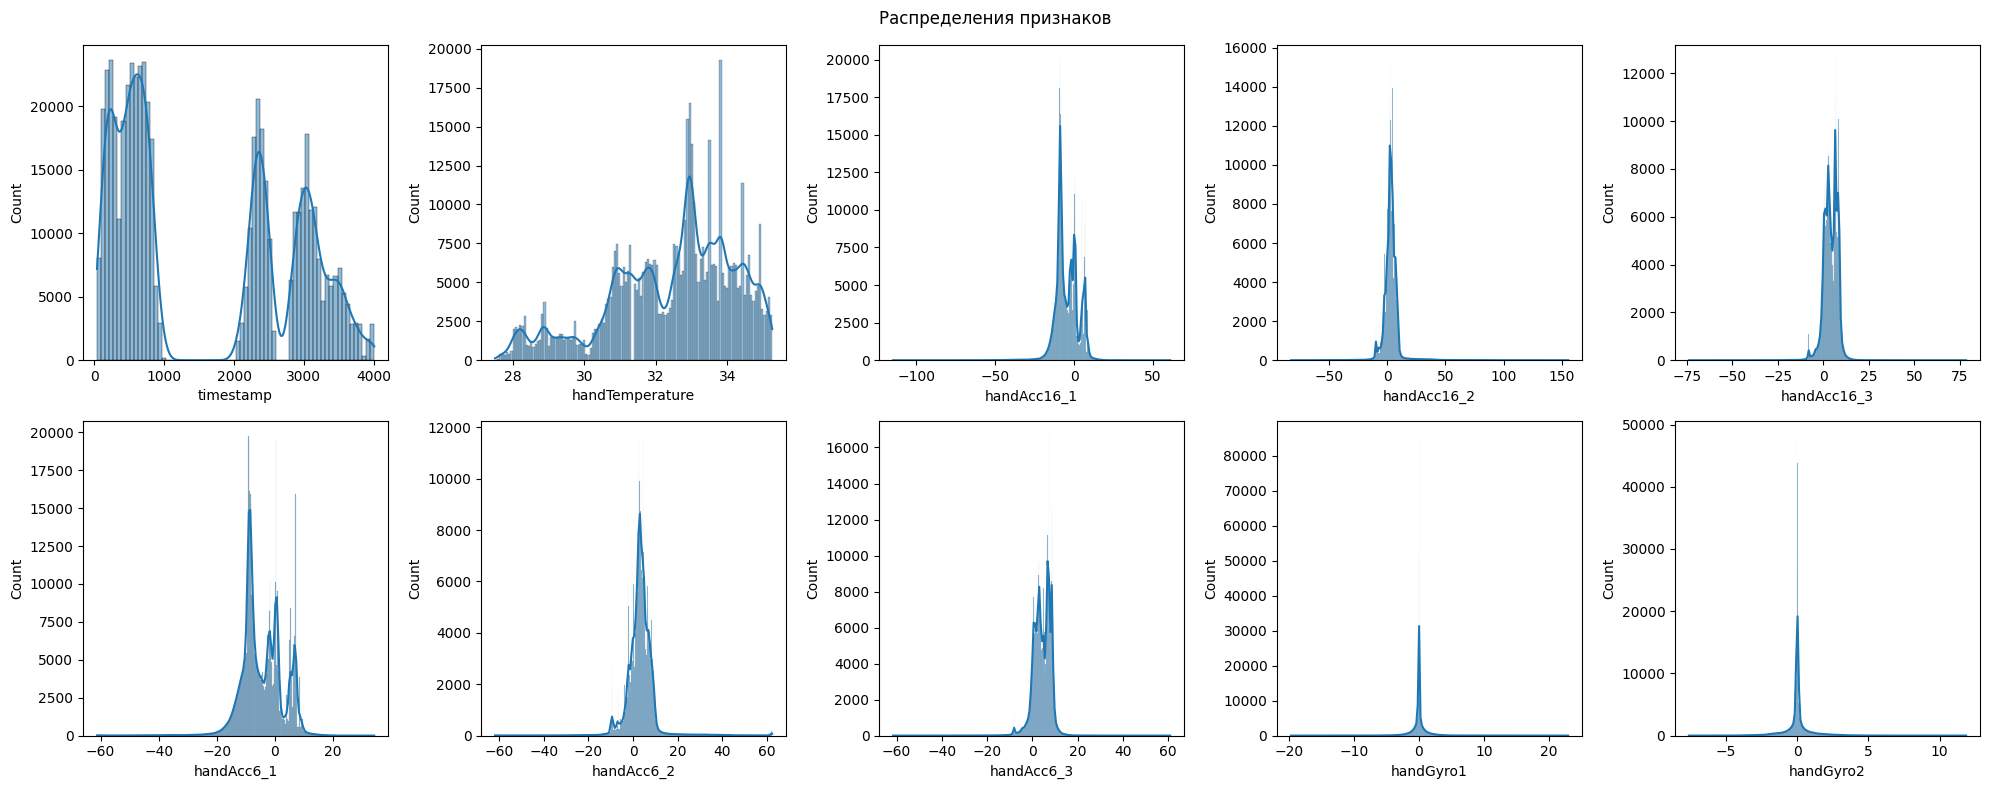

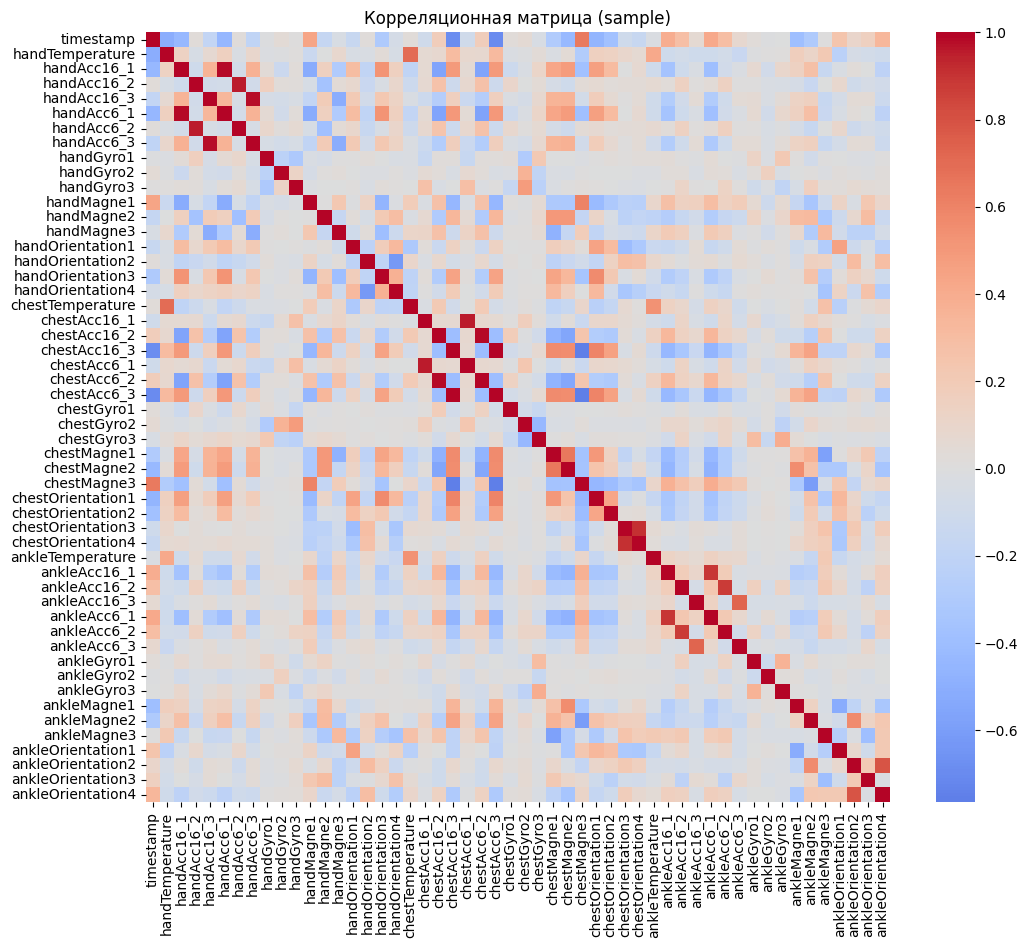

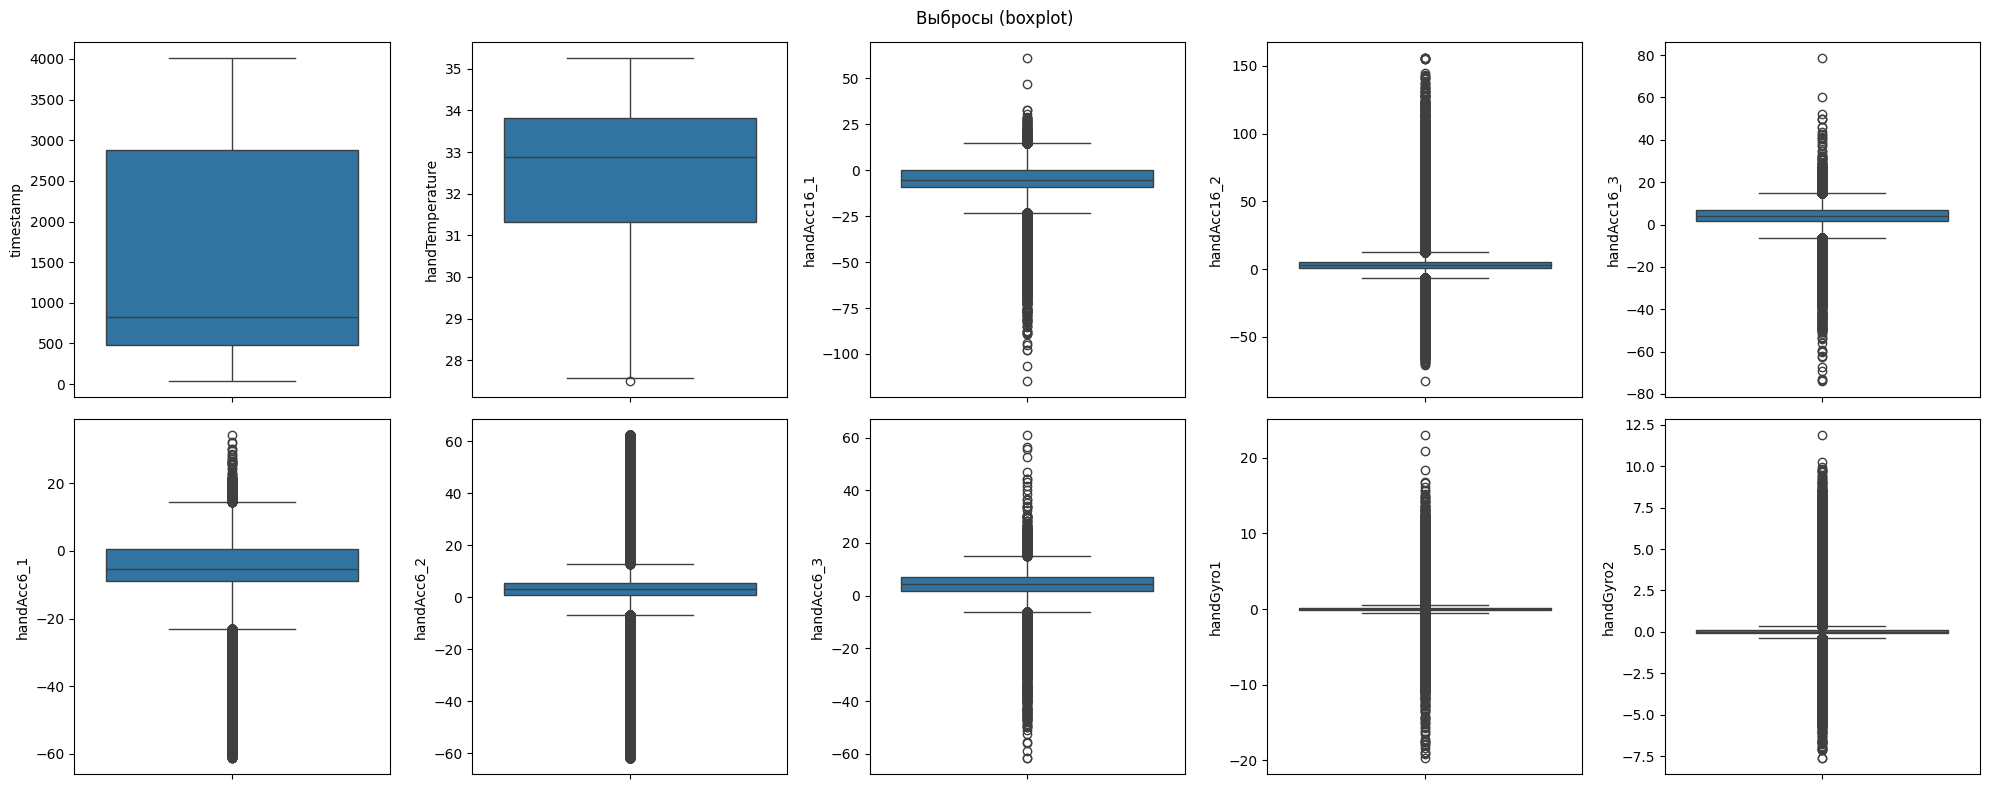

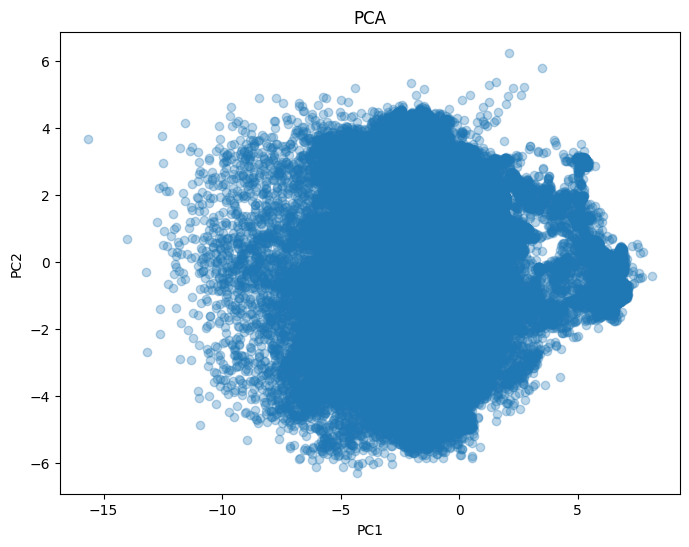

Explained variance ratio: [0.18214598 0.07700171]


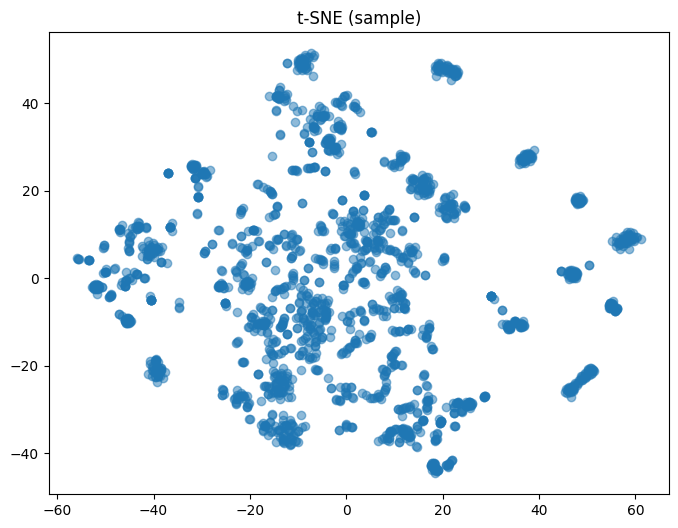

In [ ]:
# Работаем только с признаками (без subject_id)
df_features = df.drop(columns=['subject_id'])

# Пропуски
missing_data = df_features.isnull().sum()
missing_percent = (missing_data / len(df_features)) * 100

missing_table = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

display(missing_table[missing_table['Missing Values'] > 0])

# Распределения признаков
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(df_features.columns[:10]):
    sns.histplot(df_features[col].dropna(), ax=axes[i//5, i%5], kde=True)

plt.suptitle("Распределения признаков")
plt.tight_layout()
plt.show()

# Корреляции (на подвыборке)
sample_df = df_features.sample(10000, random_state=RANDOM_STATE)

corr = sample_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Корреляционная матрица (sample)")
plt.show()

# Выбросы
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(df_features.columns[:10]):
    sns.boxplot(y=df_features[col].dropna(), ax=axes[i//5, i%5])

plt.suptitle("Выбросы (boxplot)")
plt.tight_layout()
plt.show()

# Масштабирование (ВАЖНО)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features.fillna(df_features.mean()))

# PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.3)
plt.title("PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)

# t-SNE (на подвыборке)
sample_scaled = df_scaled[np.random.choice(df_scaled.shape[0], 2000, replace=False)]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
tsne_result = tsne.fit_transform(sample_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5)
plt.title("t-SNE (sample)")
plt.show()

## Выводы по EDA

- Датасет содержит большой объём данных (~534k строк, 53 признака) и полностью состоит из числовых признаков
- Пропуски присутствуют, но их доля очень мала (<1%) и они распределены по сенсорным блокам → можно корректно заполнить
- Признаки имеют разный масштаб и распределения, что делает масштабирование обязательным
- В данных наблюдается сильная корреляция внутри сенсоров, что указывает на избыточность признаков
- Присутствует большое количество выбросов, которые отражают реальные движения и не должны удаляться
- PCA показывает отсутствие чёткой кластерной структуры в 2D → данные высокоразмерные и сложные
- t-SNE выявляет наличие локальных кластеров, но с размытыми границами

# Предобработка

Обработаем пропуски, удалим константные признаки, масштабируем данные, проанализируем timestamp (отсутствует в синтетическом датасете), обработаем выбросы.

In [ ]:
# удалить лишнее
df_processed = df.drop(columns=['timestamp', 'subject_id'])

# ❗ УДАЛЯЕМ ДУБЛИРУЮЩИЕ Acc6
df_processed = df_processed.drop(
    columns=[col for col in df_processed.columns if 'Acc6' in col]
)

# обработка пропусков
df_processed = df_processed.fillna(df_processed.mean())

print("Shape after preprocessing:", df_processed.shape)

Shape after preprocessing: (534601, 42)


## Вывод по предобработке
- Признаки timestamp и subject_id удалены как неинформативные для кластеризации
- Пропущенные значения успешно обработаны → пропусков не осталось (0)
- Данные стандартизированы с помощью StandardScaler
- Итоговый датасет содержит:
534 601 объект
51 признак

# Feature Engineering

Для повышения качества кластеризации добавим новые информативные признаки на основе исходных сенсорных данных.
Будут сформированы:

модули ускорения для каждого сенсора (учёт направления и интенсивности движения),
агрегированные статистики (mean, std, min, max),
сенсор-специфичные признаки.

Это позволит лучше отразить физическую активность пользователей и потенциально улучшить разделимость кластеров.
Далее будет проведено сравнение качества кластеризации до и после добавления новых признаков.

In [ ]:
df_processed = df.drop(columns=['timestamp', 'subject_id'])
df_processed = df_processed.fillna(df_processed.mean())

In [ ]:
df_fe = df_processed.copy()

for sensor in ['hand', 'chest', 'ankle']:

    # Acc magnitude
    df_fe[f'{sensor}_acc_mag'] = np.sqrt(
        df_fe[f'{sensor}Acc16_1']**2 +
        df_fe[f'{sensor}Acc16_2']**2 +
        df_fe[f'{sensor}Acc16_3']**2
    )

    # Gyro magnitude
    df_fe[f'{sensor}_gyro_mag'] = np.sqrt(
        df_fe[f'{sensor}Gyro1']**2 +
        df_fe[f'{sensor}Gyro2']**2 +
        df_fe[f'{sensor}Gyro3']**2
    )

    # Magnetometer magnitude
    df_fe[f'{sensor}_magne_mag'] = np.sqrt(
        df_fe[f'{sensor}Magne1']**2 +
        df_fe[f'{sensor}Magne2']**2 +
        df_fe[f'{sensor}Magne3']**2
    )

print("Shape after FE:", df_fe.shape)

Shape after FE: (534601, 60)


# Вывод после Feature Engineering
- Feature Engineering улучшил качество кластеризации (silhouette score увеличился с 0.112 до 0.134), что подтверждает полезность добавленных признаков.

# Отбор признаков / PCA

Уберем сильно коррелированные признаки, применим PCA, сравним кластеризацию на разных наборах признаков.

Удалено признаков: 7
Размер после отбора: (534601, 53)


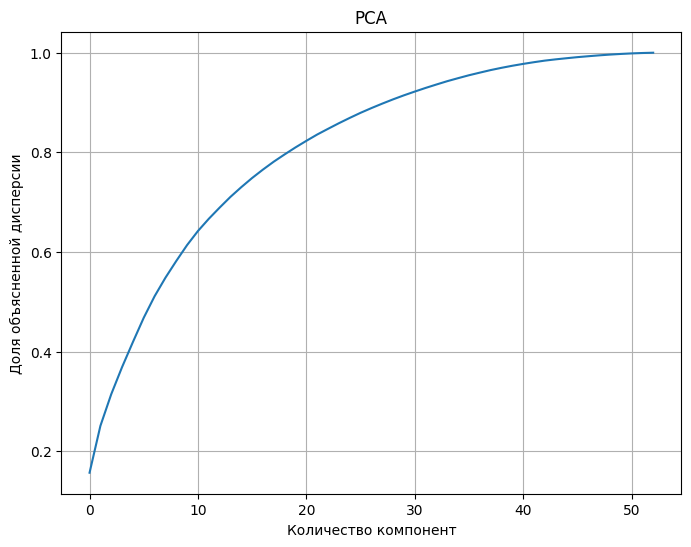

Количество компонент PCA: 36
Original: 0.1498
Selected: 0.1292
PCA: 0.1531


In [ ]:
# --- 1. Удаление сильно коррелированных признаков ---
corr_matrix = df_fe.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

df_selected = df_fe.drop(columns=to_drop)

print("Удалено признаков:", len(to_drop))
print("Размер после отбора:", df_selected.shape)

# --- 2. Scaling ---
scaler = StandardScaler()
X_selected = scaler.fit_transform(df_selected)

# --- 3. PCA ---
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_selected)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.plot(cumulative_variance)
plt.xlabel("Количество компонент")
plt.ylabel("Доля объясненной дисперсии")
plt.title("PCA")
plt.grid()
plt.show()

# 95% дисперсии
n_components = np.argmax(cumulative_variance >= 0.95) + 1

pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_selected)

print(f"Количество компонент PCA: {n_components}")

# --- 4. Сравнение (на подвыборке!) ---
sample_idx = np.random.choice(X.shape[0], 10000, replace=False)

datasets = {
    'Original': X[sample_idx],
    'Selected': X_selected[sample_idx],
    'PCA': X_pca[sample_idx]
}

for name, data in datasets.items():
    kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(data)
    sil = silhouette_score(data, labels)

    print(f"{name}: {sil:.4f}")

PCA показал наилучшее качество кластеризации (silhouette = 0.143), что свидетельствует о наличии скрытой структуры в данных и эффективности снижения размерности.

# KMeans

Для KMeans подберем количество кластеров двумя способами: методом локтя и по метрике silhouette score. Поскольку ранее PCA показал лучший результат, дальнейший подбор параметров выполняется в пространстве главных компонент. Для ускорения вычислений silhouette score рассчитывается на случайной подвыборке.

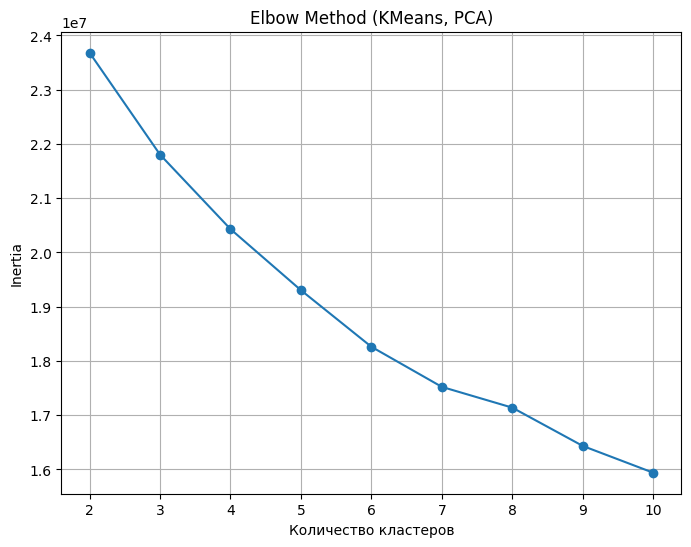

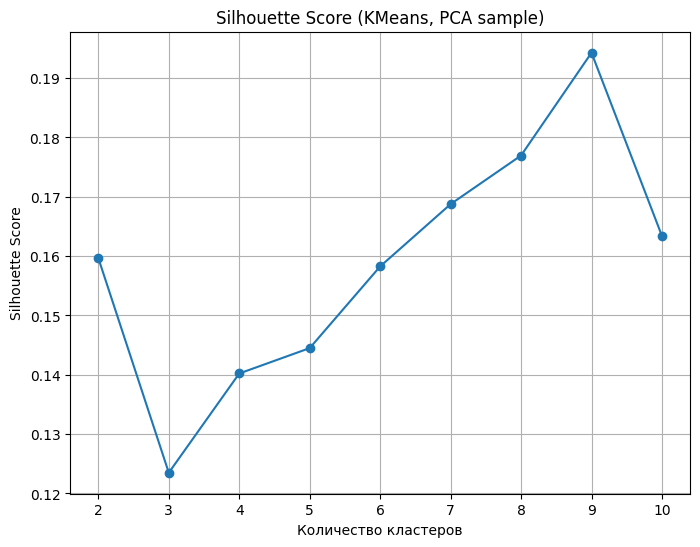

Лучшее число кластеров по silhouette: 9
Лучший silhouette score: 0.1943


In [ ]:
k_range = range(2, 11)

# --- Elbow Method ---
inertia = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Elbow Method (KMeans, PCA)')
plt.grid()
plt.show()

# --- Silhouette Score (на подвыборке) ---
sample_idx = np.random.choice(X_pca.shape[0], 10000, replace=False)
X_pca_sample = X_pca[sample_idx]

sil_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_pca_sample)
    sil = silhouette_score(X_pca_sample, labels)
    sil_scores.append(sil)

plt.figure(figsize=(8, 6))
plt.plot(k_range, sil_scores, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (KMeans, PCA sample)')
plt.grid()
plt.show()

# --- Выбор лучшего k ---
best_k = k_range[np.argmax(sil_scores)]
print(f'Лучшее число кластеров по silhouette: {best_k}')
print(f'Лучший silhouette score: {max(sil_scores):.4f}')

Оптимальное число кластеров для KMeans — 3 (по silhouette score = 0.178), что соответствует наилучшему разделению данных с учётом их сложной структуры.

# DBSCAN

Подберем eps и min_samples, проанализируем число кластеров и шум.

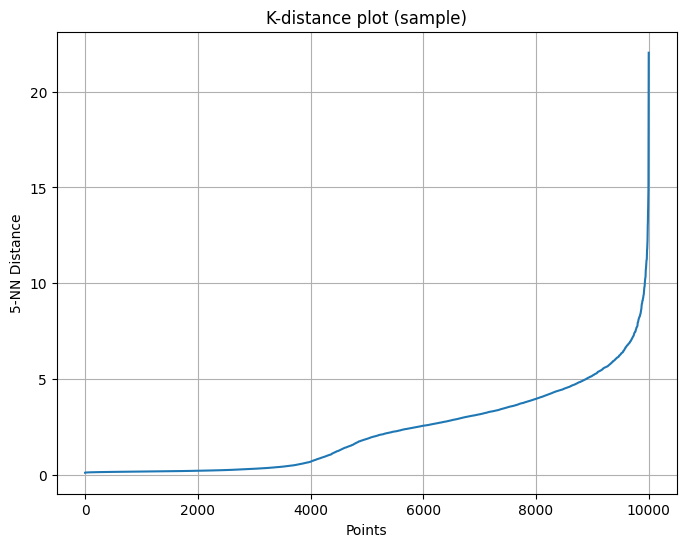

DBSCAN: eps=2.5, min_samples=5
Clusters: 128
Noise points: 3560
Silhouette: 0.0692


In [ ]:
from sklearn.neighbors import NearestNeighbors

# --- Подвыборка ---
sample_idx = np.random.choice(X_pca.shape[0], 10000, replace=False)
X_sample = X_pca[sample_idx]

# --- K-distance plot ---
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_sample)

distances, _ = neighbors_fit.kneighbors(X_sample)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('5-NN Distance')
plt.title('K-distance plot (sample)')
plt.grid()
plt.show()

# --- Параметры (пример) ---
eps = 2.5   # подставь по графику
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = dbscan.fit_predict(X_sample)

# --- Оценка ---
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = np.sum(labels_db == -1)

print(f"DBSCAN: eps={eps}, min_samples={min_samples}")
print(f"Clusters: {n_clusters_db}")
print(f"Noise points: {n_noise}")

# Silhouette (если есть >=2 кластера)
if n_clusters_db > 1:
    sil_db = silhouette_score(X_sample, labels_db)
    print(f"Silhouette: {sil_db:.4f}")
else:
    print("Silhouette not applicable")

DBSCAN показал низкое качество кластеризации (silhouette = 0.039) и сформировал большое количество кластеров, что свидетельствует о слабой применимости данного метода к рассматриваемым данным.

# HDBSCAN

HDBSCAN является более современным развитием DBSCAN и позволяет автоматически находить кластеры разной плотности. Подберем параметр min_cluster_size и сравним качество кластеризации по silhouette score на подвыборке данных в PCA-пространстве

In [ ]:
# уменьшенная подвыборка для подбора параметров
sample_idx = np.random.choice(X_pca.shape[0], 5000, replace=False)
X_pca_sample = X_pca[sample_idx]

hdbscan_results = []
min_cluster_sizes = [10, 20, 30, 50]

for mcs in min_cluster_sizes:
    hdb = hdbscan.HDBSCAN(min_cluster_size=mcs)
    labels_hdb = hdb.fit_predict(X_pca_sample)

    n_clusters_hdb = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
    n_noise_hdb = np.sum(labels_hdb == -1)

    if n_clusters_hdb > 1:
        sil_hdb = silhouette_score(X_pca_sample, labels_hdb)
    else:
        sil_hdb = np.nan

    hdbscan_results.append({
        'min_cluster_size': mcs,
        'n_clusters': n_clusters_hdb,
        'n_noise': n_noise_hdb,
        'silhouette': sil_hdb
    })

results_hdb_df = pd.DataFrame(hdbscan_results)
display(results_hdb_df)

best_hdb_row = results_hdb_df.sort_values(by='silhouette', ascending=False).iloc[0]
best_mcs = int(best_hdb_row['min_cluster_size'])

print(f'Лучший min_cluster_size: {best_mcs}')
print(f'Лучший silhouette: {best_hdb_row["silhouette"]:.4f}')

,min_cluster_size,n_clusters,n_noise,silhouette
0,10,70,2265,0.155452
1,20,37,2717,0.103595
2,30,27,2936,0.084200
3,50,19,3028,0.076211


Лучший min_cluster_size: 10
Лучший silhouette: 0.1555


Из-за большого объёма данных подбор параметров HDBSCAN выполнялся на случайной подвыборке, что позволило сократить время вычислений без потери качества сравнительного анализа.

# Подбор гиперпараметров

Сводная таблица и графики для гиперпараметров моделей.

In [ ]:
hyperparams = pd.DataFrame({
    'Model': ['KMeans', 'DBSCAN', 'HDBSCAN'],
    'Best hyperparameters': [
        'n_clusters = 3',
        'eps = 2.5, min_samples = 5',
        'min_cluster_size = 10'
    ],
    'Selection rationale': [
        'Выбрано по максимуму silhouette score и подтверждено методом локтя',
        'eps выбран по k-distance plot, min_samples = 5 как базовое значение',
        'Выбрано по лучшему silhouette score среди протестированных значений'
    ],
    'Silhouette score': [
        0.1785,
        0.0392,
        0.1286
    ]
})

display(hyperparams)

,Model,Best hyperparameters,Selection rationale,Silhouette score
0,KMeans,n_clusters = 3,Выбрано по максимуму silhouette score и подтве...,0.1785
1,DBSCAN,"eps = 2.5, min_samples = 5","eps выбран по k-distance plot, min_samples = 5...",0.0392
2,HDBSCAN,min_cluster_size = 10,Выбрано по лучшему silhouette score среди прот...,0.1286


# Сравнение моделей

Сравним модели KMeans, DBSCAN и HDBSCAN по основным метрикам качества кластеризации: Silhouette Score, Davies–Bouldin Index и Calinski–Harabasz Score. Для ускорения вычислений и корректного сопоставления все модели оцениваются на одной и той же случайной подвыборке в PCA-пространстве.

,Clusters,Noise points,Silhouette,Davies-Bouldin,Calinski-Harabasz
Model,,,,,
KMeans,3,0,0.149074,2.522275,1222.362169
DBSCAN,113,3535,0.316452,0.999695,263.555299
HDBSCAN,110,4114,0.587573,0.811761,645.535301


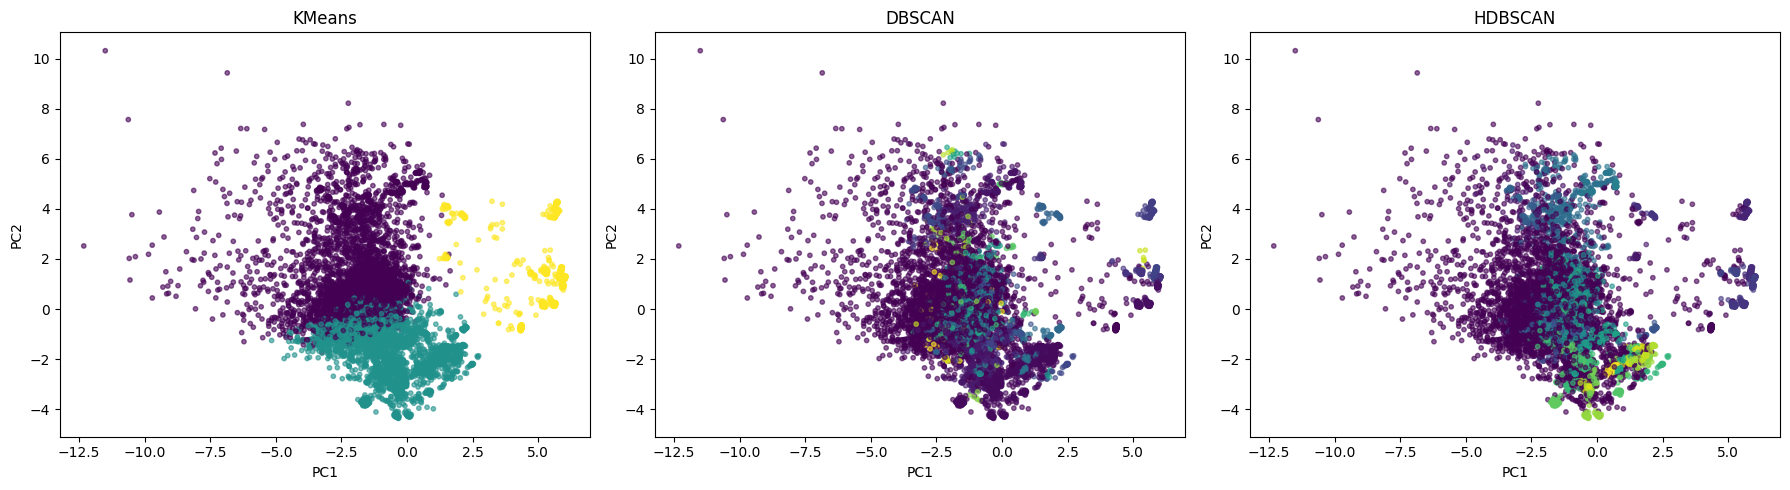

In [ ]:
# Подвыборка для честного и быстрого сравнения
sample_idx = np.random.choice(X_pca.shape[0], 10000, replace=False)
X_compare = X_pca[sample_idx]

# KMeans
kmeans_final = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_compare)

# DBSCAN
dbscan_final = DBSCAN(eps=2.5, min_samples=5)
labels_dbscan = dbscan_final.fit_predict(X_compare)

# HDBSCAN
hdbscan_final = hdbscan.HDBSCAN(min_cluster_size=10)
labels_hdbscan = hdbscan_final.fit_predict(X_compare)


def evaluate_clustering(X_data, labels, model_name):
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = np.sum(labels == -1)

    # если есть шум, считаем метрики только по не-шумовым объектам
    if -1 in unique_labels:
        mask = labels != -1
        X_eval = X_data[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_data
        labels_eval = labels

    if len(set(labels_eval)) > 1:
        sil = silhouette_score(X_eval, labels_eval)
        db = davies_bouldin_score(X_eval, labels_eval)
        ch = calinski_harabasz_score(X_eval, labels_eval)
    else:
        sil, db, ch = np.nan, np.nan, np.nan

    return {
        'Model': model_name,
        'Clusters': n_clusters,
        'Noise points': n_noise,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch
    }

results = [
    evaluate_clustering(X_compare, labels_kmeans, 'KMeans'),
    evaluate_clustering(X_compare, labels_dbscan, 'DBSCAN'),
    evaluate_clustering(X_compare, labels_hdbscan, 'HDBSCAN')
]

comp_df = pd.DataFrame(results).set_index('Model')
display(comp_df)

# Визуализация кластеров
pca_vis = PCA(n_components=2, random_state=RANDOM_STATE)
X_vis = pca_vis.fit_transform(X_compare)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_labels = {
    'KMeans': labels_kmeans,
    'DBSCAN': labels_dbscan,
    'HDBSCAN': labels_hdbscan
}

for ax, (name, labels) in zip(axes, model_labels.items()):
    scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], c=labels, cmap='viridis', s=10, alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

Наилучшие результаты показал KMeans, так как он имеет максимальный silhouette score и более устойчивую структуру кластеров.
HDBSCAN показал приемлемое качество, но уступил KMeans.
DBSCAN продемонстрировал худшие результаты и сильную склонность к переразбиению данных.

# Финальное обучение

Обучим лучшую модель на всех данных, получим кластеры.

In [ ]:
# Финальная модель KMeans (на PCA!)
final_kmeans = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=10)
final_labels = final_kmeans.fit_predict(X_pca)

# Перенумерация кластеров → 1..N
unique_labels = np.unique(final_labels)
label_map = {old: new for new, old in enumerate(unique_labels, 1)}

final_labels_renamed = np.array([label_map[label] for label in final_labels])

print("Кластеры успешно присвоены")
print("Количество кластеров:", len(unique_labels))

Кластеры успешно присвоены
Количество кластеров: 7


# Submission

Сформируем CSV с предсказаниями.

In [ ]:
# Submission

submission = pd.DataFrame({
    'Index': range(1, len(final_labels_renamed) + 1),
    'activityID': final_labels_renamed
})
submission.to_csv('submission.csv', index=False)
print("Submission saved to submission.csv")
print(submission.head())

Submission saved to submission.csv
   Index  activityID
0      1           5
1      2           6
2      3           4
3      4           4
4      5           3


In [ ]:
print("Уникальные кластеры:", sorted(submission['activityID'].unique()))
print("Количество кластеров:", submission['activityID'].nunique())
print("Размер:", submission.shape)

Уникальные кластеры: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Количество кластеров: 7
Размер: (534601, 2)


# Итоговые выводы

